Extracted 87111 shots with xg, outcome, and play_pattern
Regular Play shots: 28870
From Counter shots: 3938
Starting bootstrap for Regular Play...


Bootstrapping Regular Play: 100%|█████████████| 10/10 [00:00<00:00, 1931.70it/s]


Starting bootstrap for From Counter...


Bootstrapping From Counter: 100%|█████████████| 10/10 [00:00<00:00, 5050.94it/s]


Saved Regular Play optimality curve to /Users/jackcolvin/downloads/Optimality/Regular_play_optimality.csv
Saved From Counter optimality curve to /Users/jackcolvin/downloads/Optimality/from_counter_optimality.csv


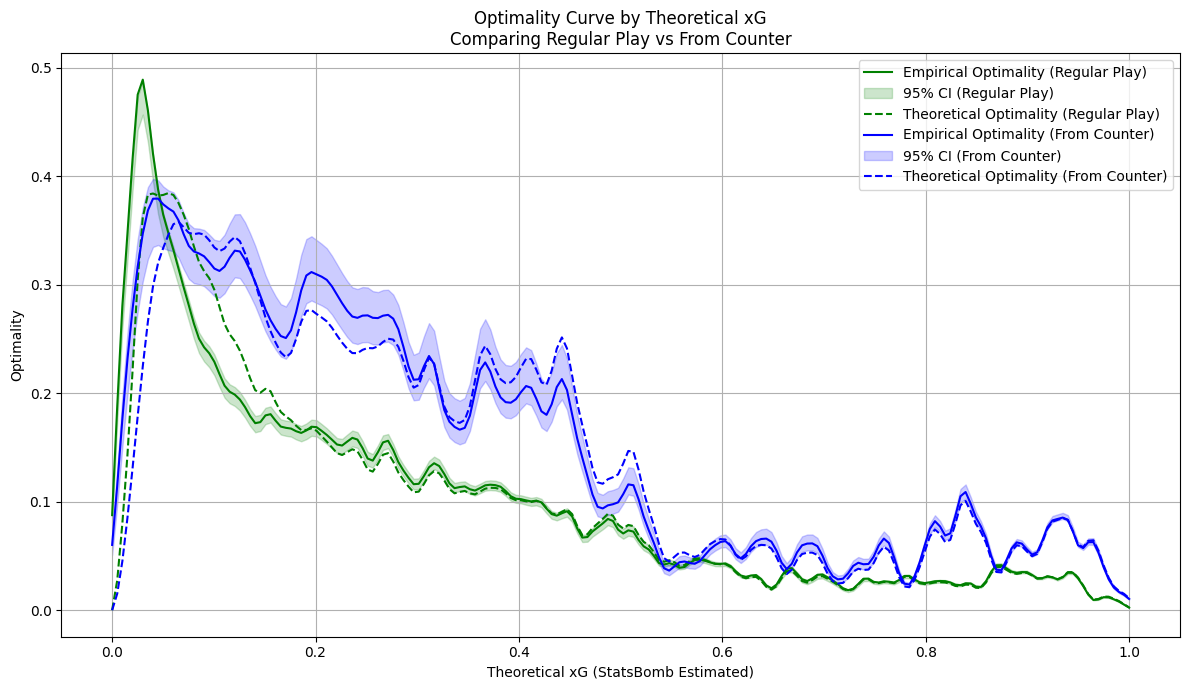

In [3]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed
from tqdm import tqdm


events_folder = "/Users/jackcolvin/downloads/json1" 

rows = []
for filename in os.listdir(events_folder):
    if filename.endswith(".json"):
        filepath = os.path.join(events_folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            events = json.load(f)
            for event in events:
                if event.get("type", {}).get("name") == "Shot":
                    xg = event.get("shot", {}).get("statsbomb_xg", None)
                    outcome = event.get("shot", {}).get("outcome", {}).get("name", None)
                    play_pattern = event.get("play_pattern", {}).get("name", None)
                    if xg is not None and outcome is not None and play_pattern is not None:
                        rows.append({
                            "xg": xg,
                            "outcome": outcome,
                            "play_pattern": play_pattern
                        })

df = pd.DataFrame(rows)
print(f"Extracted {len(df)} shots with xg, outcome, and play_pattern")


df = df.dropna(subset=["xg", "outcome", "play_pattern"]).copy()
df["goal"] = df["outcome"].apply(lambda x: 1 if x == "Goal" else 0)

# Filter only shots with play_pattern "Regular Play" or "From Counter"
regular_play_df = df[df["play_pattern"] == "Regular Play"].copy()
counter_df = df[df["play_pattern"] == "From Counter"].copy()

print(f"Regular Play shots: {len(regular_play_df)}")
print(f"From Counter shots: {len(counter_df)}")

x_vals = np.linspace(0, 1, 200)

def density_to_frac(d):
    return np.clip(0.1 - d * 0.08, 0.02, 0.1)

def _smooth_point(x0, df_x, df_y, local_fracs, x_range):
    idx_closest = np.argmin(np.abs(df_x - x0))
    frac = local_fracs[idx_closest]
    window = frac * x_range

    subset_mask = np.abs(df_x - x0) <= window
    if np.sum(subset_mask) < 5:
        expand = window
        while np.sum(subset_mask) < 5 and expand < x_range:
            expand += 0.01
            subset_mask = np.abs(df_x - x0) <= expand

    x_sub = df_x[subset_mask]
    y_sub = df_y[subset_mask]

    if len(x_sub) < 5:
        return np.mean(y_sub) if len(y_sub) > 0 else 0

    smoothed_sub = lowess(y_sub, x_sub, frac=1.0, return_sorted=False)
    return np.interp(x0, x_sub, smoothed_sub)

def kernel_smooth(x_vals, df_x, df_y, bandwidth=0.05):
    df_x = np.asarray(df_x)
    df_y = np.asarray(df_y)
    smoothed_vals = []
    for x0 in x_vals:
        weights = np.exp(-0.5 * ((df_x - x0) / bandwidth) ** 2)
        weights /= weights.sum()
        smoothed_val = np.sum(weights * df_y)
        smoothed_vals.append(smoothed_val)
    return np.array(smoothed_vals)

def compute_optimality_curve(df_subset, label, use_kernel_smooth=True):
    df_subset = df_subset.sort_values("xg")
    kde = gaussian_kde(df_subset["xg"].values, bw_method=0.05)
    densities = kde(df_subset["xg"].values)
    densities_norm = (densities - densities.min()) / (densities.max() - densities.min())
    local_fracs = density_to_frac(densities_norm)

    if use_kernel_smooth:
        smoothed_goal_rate = kernel_smooth(x_vals, df_subset["xg"].values, df_subset["goal"].values, bandwidth=0.05)
    else:
        smoothed_goal_rate = np.array(
            Parallel(n_jobs=-1)(
                delayed(_smooth_point)(x0, df_subset["xg"].values, df_subset["goal"].values, local_fracs, 1.0)
                for x0 in tqdm(x_vals, desc=f"Adaptive smoothing {label}")
            )
        )

    shot_density = kde(x_vals)

    n_bootstraps = 10
    np.random.seed(42)
    def run_bootstrap(_):
        sample_indices = np.random.choice(df_subset.index, size=len(df_subset), replace=True)
        sample = df_subset.loc[sample_indices].sort_values("xg")

        try:
            if sample["xg"].std() < 1e-5 or np.allclose(
                np.quantile(sample["xg"], [0.1, 0.9]),
                np.quantile(df_subset["xg"], [0.1, 0.9]),
                atol=0.01
            ):
                kde_sample = kde
            else:
                kde_sample = gaussian_kde(sample["xg"].values, bw_method=0.05)
        except np.linalg.LinAlgError:
            kde_sample = kde

        densities_sample = kde_sample(sample["xg"].values)
        densities_norm_sample = (densities_sample - densities_sample.min()) / (densities_sample.max() - densities_sample.min())
        local_fracs_sample = density_to_frac(densities_norm_sample)

        if use_kernel_smooth:
            return kernel_smooth(x_vals, sample["xg"].values, sample["goal"].values, bandwidth=0.05)
        else:
            return np.array([
                _smooth_point(x0, sample["xg"].values, sample["goal"].values, local_fracs_sample, 1.0)
                for x0 in x_vals
            ])

    print(f"Starting bootstrap for {label}...")
    bootstrapped_curves = np.array(
        Parallel(n_jobs=-1)(
            delayed(run_bootstrap)(i) for i in tqdm(range(n_bootstraps), desc=f"Bootstrapping {label}")
        )
    )

    lower_ci = np.percentile(bootstrapped_curves, 2.5, axis=0)
    upper_ci = np.percentile(bootstrapped_curves, 97.5, axis=0)

    optimality = smoothed_goal_rate * shot_density
    optimality_lower = lower_ci * shot_density
    optimality_upper = upper_ci * shot_density
    theoretical_optimality = x_vals * shot_density

    return {
        "label": label,
        "x_vals": x_vals,
        "optimality": optimality,
        "optimality_lower": optimality_lower,
        "optimality_upper": optimality_upper,
        "theoretical_optimality": theoretical_optimality,
        "color": "green" if label == "Regular Play" else "blue"
    }

def save_optimality_data_to_csv(results_dict, filename):
    data = {
        "xg": results_dict["x_vals"],
        "empirical_optimality": results_dict["optimality"],
        "optimality_lower": results_dict["optimality_lower"],
        "optimality_upper": results_dict["optimality_upper"],
        "theoretical_optimality": results_dict["theoretical_optimality"]
    }
    df_out = pd.DataFrame(data)
    df_out.to_csv(filename, index=False)
    print(f"Saved {results_dict['label']} optimality curve to {filename}")

# === Compute and Save ===
regular_results = compute_optimality_curve(regular_play_df, "Regular Play", use_kernel_smooth=True)
counter_results = compute_optimality_curve(counter_df, "From Counter", use_kernel_smooth=True)

save_optimality_data_to_csv(regular_results, "/Users/jackcolvin/downloads/Optimality/Regular_play_optimality.csv")
save_optimality_data_to_csv(counter_results, "/Users/jackcolvin/downloads/Optimality/from_counter_optimality.csv")

# === Plot ===
plt.figure(figsize=(12, 7))
for res in [regular_results, counter_results]:
    plt.plot(res["x_vals"], res["optimality"], label=f"Empirical Optimality ({res['label']})", color=res["color"])
    plt.fill_between(res["x_vals"], res["optimality_lower"], res["optimality_upper"], color=res["color"], alpha=0.2, label=f"95% CI ({res['label']})")
    plt.plot(res["x_vals"], res["theoretical_optimality"], label=f"Theoretical Optimality ({res['label']})", color=res["color"], linestyle="--")

plt.title("Optimality Curve by Theoretical xG\nComparing Regular Play vs From Counter")
plt.xlabel("Theoretical xG (StatsBomb Estimated)")
plt.ylabel("Optimality")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("optimality_reg_vs_counter.png", dpi=300)
plt.show()